# AI 600 — Assignment 3 (Colab)

**Runtime → Change runtime type → GPU (T4 is enough).**

This notebook runs:
- **Task 1A:** MNIST custom CNN (≤3 conv, ≤2 FC, &lt;50k params)
- **Task 1B:** C-MNIST from your three `.pt` files on **Google Drive** (paths cell)
- **Task 2:** STL-10 + frozen ResNet-18 backbone + trainable head + GradCAM


In [1]:
# Installs (Colab often has torch preinstalled; grad-cam is required for Task 2)
%pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

device: cuda
Tesla T4


In [3]:
# --- Paths (Colab) ---
from google.colab import drive

drive.mount("/content/drive")

# Folder on Drive that contains train_biased.pt, test_biased.pt, test_unbiased.pt
# Change this if you put `cmnist` somewhere else (e.g. a shared drive path).
CMNIST_DIR = Path("/content/drive/MyDrive/cmnist")

WORK = Path("/content/ai600_pa3")
WORK.mkdir(parents=True, exist_ok=True)
DATA_ROOT = WORK / "data"
DATA_ROOT.mkdir(exist_ok=True)
RUNS = WORK / "runs"
RUNS.mkdir(exist_ok=True)

# Training knobs (tweak if needed)
BATCH_MNIST = 128
BATCH_CMNIST = 128
BATCH_STL = 64
EPOCHS_MNIST = 10
EPOCHS_CMNIST = 12
EPOCHS_STL = 20
LR = 1e-3

print("CMNIST_DIR (Google Drive):", CMNIST_DIR)
if CMNIST_DIR.is_dir():
    print("contents:", sorted(p.name for p in CMNIST_DIR.iterdir() if p.suffix == ".pt"))

Mounted at /content/drive
CMNIST_DIR (Google Drive): /content/drive/MyDrive/cmnist
contents: ['test_biased.pt', 'test_unbiased.pt', 'train_biased.pt']


## C-MNIST data

The path cell above mounts Drive and sets **`CMNIST_DIR = /content/drive/MyDrive/cmnist`**. That folder should contain:
- `train_biased.pt`
- `test_biased.pt`
- `test_unbiased.pt`

If your folder lives elsewhere, edit **`CMNIST_DIR`** in that cell.

In [4]:
required = ["train_biased.pt", "test_biased.pt", "test_unbiased.pt"]
for r in required:
    p = CMNIST_DIR / r
    assert p.is_file(), f"Missing {p} — check Drive folder {CMNIST_DIR}"
print("All C-MNIST files present.")

All C-MNIST files present.


## Model + training utilities

Constraint check: **3 conv**, **2 FC**, **&lt; 50,000** trainable parameters.

In [5]:
def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


class SmallCNN(nn.Module):
    def __init__(self, in_ch: int = 1, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 12, 3, padding=1)
        self.conv2 = nn.Conv2d(12, 24, 3, padding=1)
        self.conv3 = nn.Conv2d(24, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def train_loop(model, train_loader, val_loader, device, epochs: int, lr: float):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()
        tl, tc, tn = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            tl += loss.item() * x.size(0)
            tc += (logits.argmax(1) == y).sum().item()
            tn += x.size(0)
        model.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                vl += crit(logits, y).item() * x.size(0)
                vc += (logits.argmax(1) == y).sum().item()
                vn += x.size(0)
        hist["train_loss"].append(tl / tn)
        hist["val_loss"].append(vl / vn)
        hist["train_acc"].append(tc / tn)
        hist["val_acc"].append(vc / vn)
        print(
            f"epoch {ep+1}/{epochs}  train_loss={hist['train_loss'][-1]:.4f}  "
            f"val_loss={hist['val_loss'][-1]:.4f}  val_acc={hist['val_acc'][-1]:.4f}"
        )
    return hist


def plot_curves(hist, path: Path, title: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(hist["train_acc"], label="train")
    ax[1].plot(hist["val_acc"], label="val")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close()


def plot_first_conv_filters(model: SmallCNN, path: Path, in_ch: int):
    w = model.conv1.weight.detach().cpu()
    n = w.shape[0]
    cols = min(6, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = np.atleast_1d(axes).ravel()
    for i in range(n):
        fmap = w[i]
        if in_ch == 1:
            axes[i].imshow(fmap[0].numpy(), cmap="gray", vmin=w.min(), vmax=w.max())
        else:
            t = fmap.permute(1, 2, 0).numpy()
            t = (t - t.min()) / (t.max() - t.min() + 1e-8)
            axes[i].imshow(t)
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    fig.suptitle("First conv filters")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close()

---
## Task 1A — MNIST

Adam + cross-entropy; curves for the report; first-layer filter plot (**Analytical 1.2**).

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]


MNIST trainable params: 28826 (must be <= 50000)
epoch 1/10  train_loss=0.4344  val_loss=0.1293  val_acc=0.9627
epoch 2/10  train_loss=0.1029  val_loss=0.0948  val_acc=0.9712
epoch 3/10  train_loss=0.0731  val_loss=0.0745  val_acc=0.9772
epoch 4/10  train_loss=0.0577  val_loss=0.0687  val_acc=0.9782
epoch 5/10  train_loss=0.0494  val_loss=0.0554  val_acc=0.9835
epoch 6/10  train_loss=0.0422  val_loss=0.0480  val_acc=0.9842
epoch 7/10  train_loss=0.0358  val_loss=0.0428  val_acc=0.9867
epoch 8/10  train_loss=0.0323  val_loss=0.0420  val_acc=0.9860
epoch 9/10  train_loss=0.0290  val_loss=0.0430  val_acc=0.9865
epoch 10/10  train_loss=0.0276  val_loss=0.0515  val_acc=0.9840


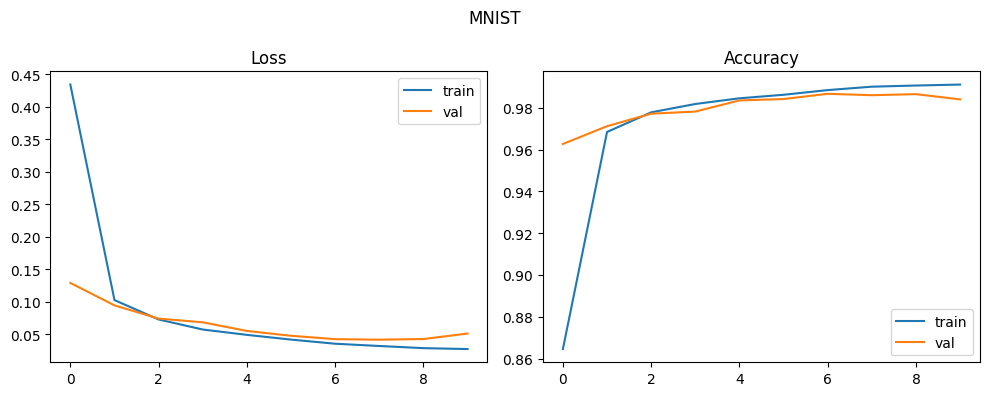

MNIST test acc: 0.9855  test loss: 0.0509


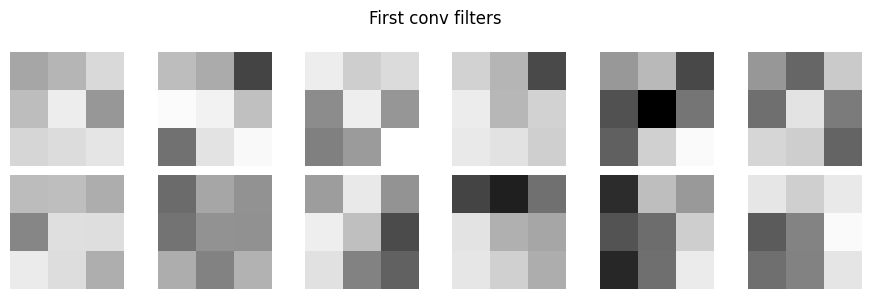

Saved: /content/ai600_pa3/runs/mnist


In [6]:
from torchvision import datasets, transforms

out_mnist = RUNS / "mnist"
out_mnist.mkdir(parents=True, exist_ok=True)

tf = transforms.Compose([transforms.ToTensor()])
train_full = datasets.MNIST(root=str(DATA_ROOT), train=True, download=True, transform=tf)
test_set = datasets.MNIST(root=str(DATA_ROOT), train=False, download=True, transform=tf)
n = len(train_full)
n_val = int(0.1 * n)
train_set, val_set = random_split(
    train_full, [n - n_val, n_val], generator=torch.Generator().manual_seed(42)
)
tr = DataLoader(train_set, batch_size=BATCH_MNIST, shuffle=True, num_workers=0, pin_memory=True)
va = DataLoader(val_set, batch_size=BATCH_MNIST, shuffle=False, num_workers=0, pin_memory=True)
te = DataLoader(test_set, batch_size=BATCH_MNIST, shuffle=False, num_workers=0, pin_memory=True)

model_mnist = SmallCNN(in_ch=1).to(device)
nc = count_params(model_mnist)
print("MNIST trainable params:", nc, "(must be <= 50000)")
assert nc <= 50000

hist_m = train_loop(model_mnist, tr, va, device, EPOCHS_MNIST, LR)
plot_curves(hist_m, out_mnist / "curves_mnist.png", "MNIST")

model_mnist.eval()
crit = nn.CrossEntropyLoss()
correct = total = 0
tloss = 0.0
with torch.no_grad():
    for x, y in te:
        x, y = x.to(device), y.to(device)
        logits = model_mnist(x)
        tloss += crit(logits, y).item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
print(f"MNIST test acc: {correct/total:.4f}  test loss: {tloss/total:.4f}")

plot_first_conv_filters(model_mnist, out_mnist / "first_conv_mnist.png", in_ch=1)
torch.save(model_mnist.state_dict(), out_mnist / "mnist_cnn.pt")
print("Saved:", out_mnist)

---
## Task 1B — Colored MNIST (biased train, two test sets)

LMS tensors: `float32` in **`[0, 1]`** — **do not** divide by 255 again.

**If `torch.load` fails with “central directory” / zip errors:** the `.pt` on disk is **not** a valid save — usually **truncated upload** on Colab or a **Git LFS pointer** instead of the real file. Use **Google Drive**: upload the three full `.pt` there, then `drive.mount` and `shutil.copy` into `CMNIST_DIR`, or re-upload until `train_biased.pt` shows **~500+ MB** in the file check.

train_biased.pt: 565.0 MB
test_biased.pt: 94.2 MB
test_unbiased.pt: 94.2 MB
train images (60000, 3, 28, 28) labels (60000,) dtype torch.float32 min/max 0.0 1.0
test_biased images (10000, 3, 28, 28) labels (10000,) dtype torch.float32 min/max 0.0 1.0
test_unbiased images (10000, 3, 28, 28) labels (10000,) dtype torch.float32 min/max 0.0 1.0
C-MNIST trainable params: 29042
epoch 1/12  train_loss=0.4211  val_loss=0.1480  val_acc=0.9627
epoch 2/12  train_loss=0.0952  val_loss=0.0693  val_acc=0.9808
epoch 3/12  train_loss=0.0576  val_loss=0.0527  val_acc=0.9845
epoch 4/12  train_loss=0.0421  val_loss=0.0467  val_acc=0.9885
epoch 5/12  train_loss=0.0344  val_loss=0.0417  val_acc=0.9902
epoch 6/12  train_loss=0.0305  val_loss=0.0499  val_acc=0.9863
epoch 7/12  train_loss=0.0257  val_loss=0.0374  val_acc=0.9893
epoch 8/12  train_loss=0.0243  val_loss=0.0511  val_acc=0.9870
epoch 9/12  train_loss=0.0204  val_loss=0.0332  val_acc=0.9927
epoch 10/12  train_loss=0.0191  val_loss=0.0331  val_acc=0.

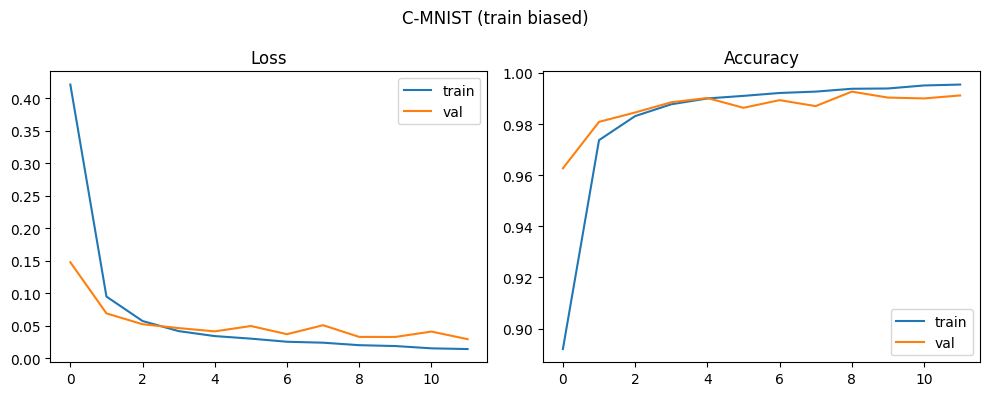

biased test accuracy: 0.9938
unbiased test accuracy: 0.9192


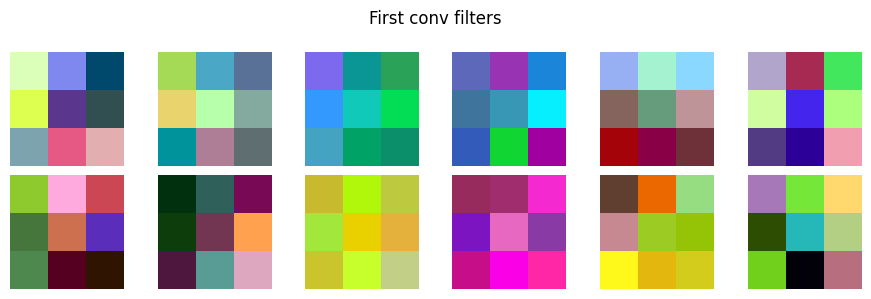

Saved: /content/ai600_pa3/runs/cmnist


In [7]:
def verify_pt_file(p: Path) -> None:
    if not p.is_file():
        raise FileNotFoundError(f"Missing: {p}")
    n = p.stat().st_size
    print(f"{p.name}: {n / 1e6:.1f} MB")
    with open(p, "rb") as f:
        head = f.read(200)
    if b"git-lfs.github.com" in head or (head.startswith(b"version") and b"oid" in head):
        raise RuntimeError(
            f"{p.name} is a Git LFS pointer text file, not PyTorch data. "
            "Download the real .pt from LMS (or run `git lfs pull`) and upload that binary."
        )
    if "train" in p.name.lower() and n < 400 * 1024**2:
        raise RuntimeError(
            f"{p.name} is only {n/1e6:.0f} MB; full train tensors are usually ~500+ MB. "
            "Colab uploads often truncate — use Drive (mount + copy) or re-upload."
        )
    if "test" in p.name.lower() and n < 40 * 1024**2:
        raise RuntimeError(
            f"{p.name} is only {n/1e6:.0f} MB; expect ~90+ MB for 10k RGB 28x28 float images. Re-upload."
        )


def load_pt(p: Path):
    verify_pt_file(p)
    try:
        try:
            return torch.load(p, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(p, map_location="cpu")
    except RuntimeError as e:
        msg = str(e).lower()
        if "zip" in msg or "central directory" in msg or "streamreader" in msg:
            raise RuntimeError(
                f"torch.load cannot read {p.name}: file is corrupt or incomplete. "
                "Re-download from LMS and copy the full file (Drive > /content/... or re-upload)."
            ) from e
        raise


train_pack = load_pt(CMNIST_DIR / "train_biased.pt")
test_b = load_pt(CMNIST_DIR / "test_biased.pt")
test_u = load_pt(CMNIST_DIR / "test_unbiased.pt")

for name, tup in [("train", train_pack), ("test_biased", test_b), ("test_unbiased", test_u)]:
    x, y = tup[0], tup[1]
    print(name, "images", tuple(x.shape), "labels", tuple(y.shape), "dtype", x.dtype, "min/max", float(x.min()), float(x.max()))


def as_loader(tup, batch, shuffle):
    x, y = tup[0].float(), tup[1].long()
    return DataLoader(TensorDataset(x, y), batch_size=batch, shuffle=shuffle, num_workers=0)


out_c = RUNS / "cmnist"
out_c.mkdir(parents=True, exist_ok=True)

n = train_pack[0].shape[0]
n_val = max(1, int(0.1 * n))
x, y = train_pack[0].float(), train_pack[1].long()
full = TensorDataset(x, y)
train_d, val_d = random_split(full, [n - n_val, n_val], generator=torch.Generator().manual_seed(42))
tr_c = DataLoader(train_d, batch_size=BATCH_CMNIST, shuffle=True, num_workers=0)
va_c = DataLoader(val_d, batch_size=BATCH_CMNIST, shuffle=False, num_workers=0)
loader_biased = as_loader(test_b, BATCH_CMNIST, False)
loader_unbiased = as_loader(test_u, BATCH_CMNIST, False)

model_c = SmallCNN(in_ch=3).to(device)
print("C-MNIST trainable params:", count_params(model_c))

hist_c = train_loop(model_c, tr_c, va_c, device, EPOCHS_CMNIST, LR)
plot_curves(hist_c, out_c / "curves_cmnist.png", "C-MNIST (train biased)")


def eval_acc(name, ld, model):
    model.eval()
    ok = tot = 0
    with torch.no_grad():
        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)
            ok += (model(xb).argmax(1) == yb).sum().item()
            tot += xb.size(0)
    acc = ok / tot
    print(f"{name} accuracy: {acc:.4f}")
    return acc


acc_b = eval_acc("biased test", loader_biased, model_c)
acc_u = eval_acc("unbiased test", loader_unbiased, model_c)
with open(out_c / "cmnist_results.txt", "w") as f:
    f.write(f"biased_test_acc={acc_b}\nunbiased_test_acc={acc_u}\n")

plot_first_conv_filters(model_c, out_c / "first_conv_cmnist.png", in_ch=3)
torch.save(model_c.state_dict(), out_c / "cmnist_cnn.pt")
print("Saved:", out_c)

---
## Task 2A — STL-10, ResNet-18, frozen backbone, train head only

First run downloads STL-10 (~3GB) into `DATA_ROOT`.

In [8]:
from torchvision import models, transforms
from torchvision.datasets import STL10

out_s = RUNS / "stl10"
out_s.mkdir(parents=True, exist_ok=True)

tf_train = transforms.Compose(
    [
        transforms.RandomCrop(96, padding=8),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)
tf_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

train_ds = STL10(root=str(DATA_ROOT), split="train", download=True, transform=tf_train)
test_ds = STL10(root=str(DATA_ROOT), split="test", download=True, transform=tf_test)
tr_s = DataLoader(train_ds, batch_size=BATCH_STL, shuffle=True, num_workers=0, pin_memory=True)

m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in m.parameters():
    p.requires_grad = False
m.fc = nn.Linear(m.fc.in_features, 10)
m = m.to(device)

opt = torch.optim.Adam(m.fc.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

for ep in range(EPOCHS_STL):
    m.train()
    tl, tc, tn = 0.0, 0, 0
    for x, y in tr_s:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = m(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()
        tl += loss.item() * x.size(0)
        tc += (logits.argmax(1) == y).sum().item()
        tn += x.size(0)
    print(f"STL-10 epoch {ep+1}/{EPOCHS_STL} train_loss={tl/tn:.4f} train_acc={tc/tn:.4f}")

m.eval()
ok = tot = 0
with torch.no_grad():
    for x, y in DataLoader(test_ds, batch_size=BATCH_STL, shuffle=False, num_workers=0):
        x, y = x.to(device), y.to(device)
        ok += (m(x).argmax(1) == y).sum().item()
        tot += y.size(0)
print(f"STL-10 test accuracy: {ok/tot:.4f}")

100%|██████████| 2.64G/2.64G [00:49<00:00, 53.0MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


STL-10 epoch 1/20 train_loss=1.5533 train_acc=0.4850
STL-10 epoch 2/20 train_loss=0.9334 train_acc=0.7094
STL-10 epoch 3/20 train_loss=0.8378 train_acc=0.7246
STL-10 epoch 4/20 train_loss=0.7574 train_acc=0.7440
STL-10 epoch 5/20 train_loss=0.7496 train_acc=0.7428
STL-10 epoch 6/20 train_loss=0.6941 train_acc=0.7660
STL-10 epoch 7/20 train_loss=0.6874 train_acc=0.7656
STL-10 epoch 8/20 train_loss=0.6600 train_acc=0.7752
STL-10 epoch 9/20 train_loss=0.6479 train_acc=0.7802
STL-10 epoch 10/20 train_loss=0.6497 train_acc=0.7690
STL-10 epoch 11/20 train_loss=0.6502 train_acc=0.7712
STL-10 epoch 12/20 train_loss=0.6346 train_acc=0.7858
STL-10 epoch 13/20 train_loss=0.6228 train_acc=0.7840
STL-10 epoch 14/20 train_loss=0.6229 train_acc=0.7836
STL-10 epoch 15/20 train_loss=0.6227 train_acc=0.7810
STL-10 epoch 16/20 train_loss=0.6003 train_acc=0.7924
STL-10 epoch 17/20 train_loss=0.5915 train_acc=0.7934
STL-10 epoch 18/20 train_loss=0.5963 train_acc=0.7930
STL-10 epoch 19/20 train_loss=0.6017 

## Task 2B — GradCAM (2 correct + 2 wrong on test set)

Uses `layer4` last block; overlay saved under `runs/stl10/gradcam/`.

GradCAM samples — correct: 2 wrong: 2


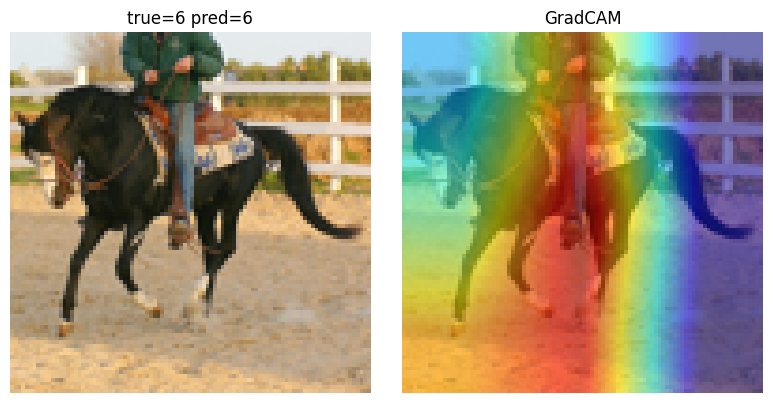

saved /content/ai600_pa3/runs/stl10/gradcam/correct_0_idx0.png


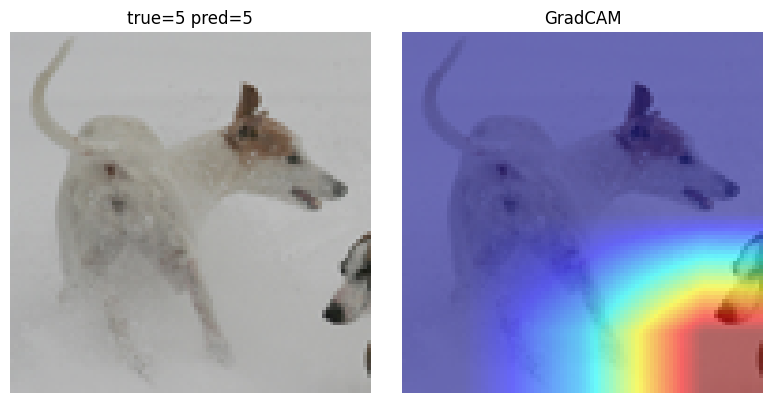

saved /content/ai600_pa3/runs/stl10/gradcam/correct_1_idx2.png


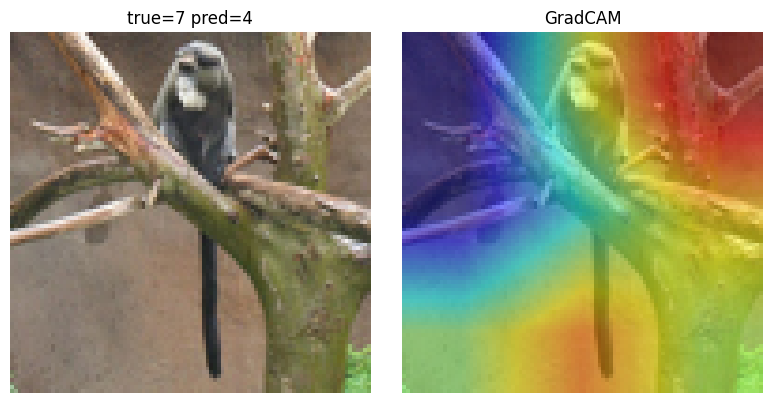

saved /content/ai600_pa3/runs/stl10/gradcam/wrong_0_idx1.png


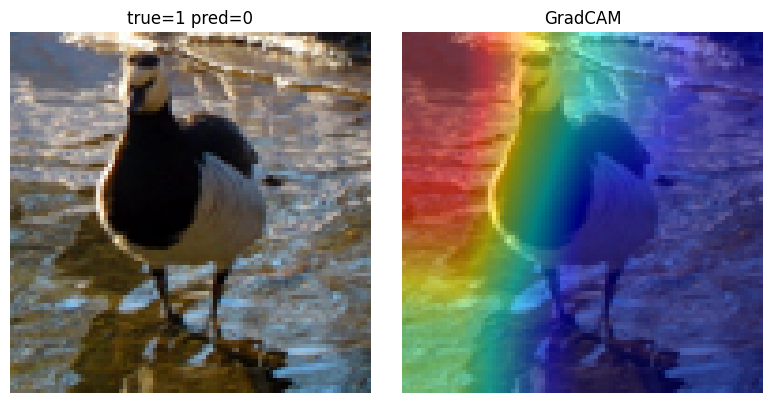

saved /content/ai600_pa3/runs/stl10/gradcam/wrong_1_idx5.png


In [11]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

te1 = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
target_layers = [m.layer4[-1]]
cam = GradCAM(model=m, target_layers=target_layers)

correct_samples = []
wrong_samples = []
idx = 0
m.eval()
with torch.no_grad():
    for x, y in te1:
        x = x.to(device)
        logits = m(x)
        pred = logits.argmax(1).item()
        y0 = y.item()
        if pred == y0 and len(correct_samples) < 2:
            correct_samples.append((idx, x.cpu(), y0, pred))
        elif pred != y0 and len(wrong_samples) < 2:
            wrong_samples.append((idx, x.cpu(), y0, pred))
        idx += 1
        if len(correct_samples) >= 2 and len(wrong_samples) >= 2:
            break
        if idx > 8000:
            break

print("GradCAM samples — correct:", len(correct_samples), "wrong:", len(wrong_samples))


def denorm_stl(t):
    t = t.clone().squeeze(0)
    for i, (mean, std) in enumerate(zip((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))):
        t[i] = t[i] * std + mean
    return t.permute(1, 2, 0).numpy().clip(0, 1)


gdir = out_s / "gradcam"
gdir.mkdir(parents=True, exist_ok=True)

# Frozen backbone: activations lack requires_grad unless we build graph from a leaf.
# Clone + requires_grad_(True) on input fixes grads=None in pytorch-grad-cam hooks.
for tag, samples in [("correct", correct_samples), ("wrong", wrong_samples)]:
    for k, (global_i, x_cpu, yt, yp) in enumerate(samples):
        with torch.enable_grad():
            x_in = x_cpu.to(device).clone().detach().requires_grad_(True)
            grayscale_cam = cam(
                input_tensor=x_in,
                targets=[ClassifierOutputTarget(yp)],
            )
        cam_img = grayscale_cam[0, :]
        rgb = denorm_stl(x_cpu)
        vis = show_cam_on_image(rgb, cam_img, use_rgb=True)
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(rgb)
        ax[0].set_title(f"true={yt} pred={yp}")
        ax[0].axis("off")
        ax[1].imshow(vis)
        ax[1].set_title("GradCAM")
        ax[1].axis("off")
        fig.tight_layout()
        fp = gdir / f"{tag}_{k}_idx{global_i}.png"
        fig.savefig(fp, dpi=150)
        plt.show()
        plt.close()
        print("saved", fp)

torch.save(m.state_dict(), out_s / "stl10_resnet18_head.pt")

---
## Download `runs/` for your report

Zip and pull figures + weights if you need them locally.

In [12]:
!zip -r /content/ai600_pa3_runs.zip /content/ai600_pa3/runs
from google.colab import files
files.download("/content/ai600_pa3_runs.zip")

  adding: content/ai600_pa3/runs/ (stored 0%)
  adding: content/ai600_pa3/runs/mnist/ (stored 0%)
  adding: content/ai600_pa3/runs/mnist/first_conv_mnist.png (deflated 43%)
  adding: content/ai600_pa3/runs/mnist/curves_mnist.png (deflated 12%)
  adding: content/ai600_pa3/runs/mnist/mnist_cnn.pt (deflated 9%)
  adding: content/ai600_pa3/runs/cmnist/ (stored 0%)
  adding: content/ai600_pa3/runs/cmnist/first_conv_cmnist.png (deflated 41%)
  adding: content/ai600_pa3/runs/cmnist/curves_cmnist.png (deflated 11%)
  adding: content/ai600_pa3/runs/cmnist/cmnist_results.txt (deflated 29%)
  adding: content/ai600_pa3/runs/cmnist/cmnist_cnn.pt (deflated 9%)
  adding: content/ai600_pa3/runs/stl10/ (stored 0%)
  adding: content/ai600_pa3/runs/stl10/stl10_resnet18_head.pt (deflated 7%)
  adding: content/ai600_pa3/runs/stl10/gradcam/ (stored 0%)
  adding: content/ai600_pa3/runs/stl10/gradcam/correct_1_idx2.png (deflated 9%)
  adding: content/ai600_pa3/runs/stl10/gradcam/correct_0_idx0.png (deflated 9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>